# 1. Import libraries
- import all needed libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 2. Import Data

In [37]:
df = pd.read_csv('StudentsPerformance.csv')

df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [38]:
df.shape

(1000, 8)

The dataset has 1000 rows and 8 columns.

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


Here we just look at all the column names, how many non-existing values we have and what data type every column has.

- no null values in the dataset
- all the data is stored as strings or integers

In [40]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 2.1 Dummy variables for strings

In [41]:
X = pd.get_dummies(
    df[['reading score', 'writing score', 'gender', 'race/ethnicity',
        'parental level of education', 'lunch', 'test preparation course']],
    drop_first=True
)

y = df['math score']

X

,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,78,75,True,False,True,False,False,False,False,False,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,99,95,False,False,False,False,True,False,False,True,False,False,True,False
996,55,55,True,False,True,False,False,False,True,False,False,False,False,True
997,71,65,False,False,True,False,False,False,True,False,False,False,False,False
998,78,77,False,False,False,True,False,False,False,False,True,False,True,False


# 3. Visualization

- every project should have a part where we visualize the data, so we can find some patterns

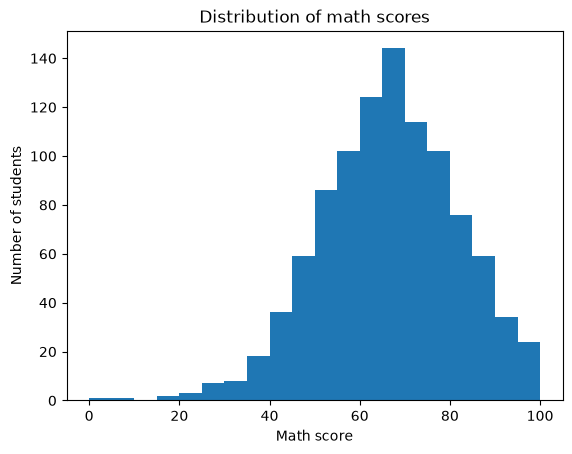

In [42]:
plt.hist(df['math score'], bins=20)
plt.xlabel('Math score')
plt.ylabel('Number of students')
plt.title('Distribution of math scores')
plt.show()

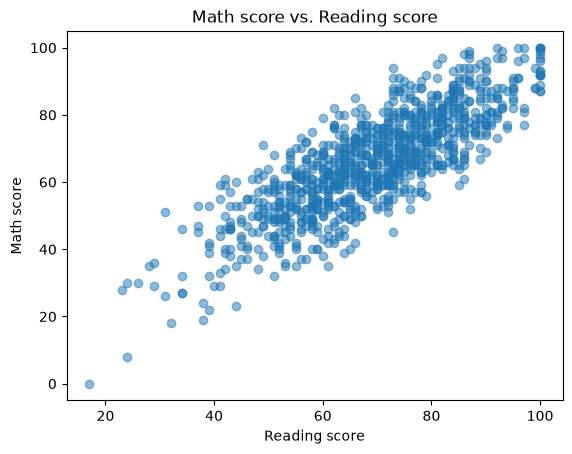

In [43]:
plt.scatter(df['reading score'], df['math score'], alpha=0.5)
plt.xlabel('Reading score')
plt.ylabel('Math score')
plt.title('Math score vs. Reading score')
plt.show()

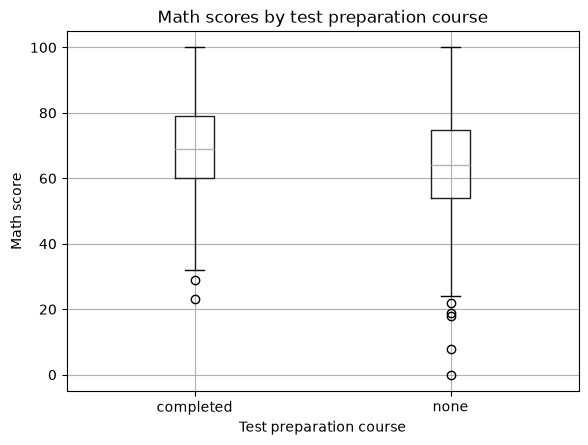

In [44]:
fig, ax = plt.subplots()
df.boxplot(column='math score', by='test preparation course', ax=ax)
ax.set_xlabel('Test preparation course')
ax.set_ylabel('Math score')
ax.set_title('Math scores by test preparation course')
plt.suptitle('')
plt.show()

Students who completed the test prep course tend to score higher on average, though there's overlap between the two groups.

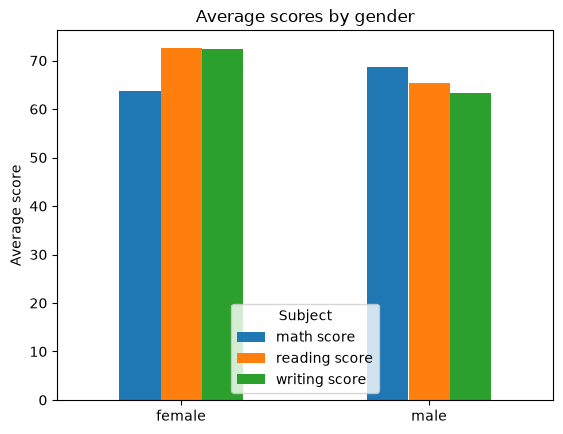

In [45]:
avg_by_gender = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()

fig, ax = plt.subplots()
avg_by_gender.plot(kind='bar', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Average score')
ax.set_title('Average scores by gender')
ax.set_xticklabels(avg_by_gender.index, rotation=0)
ax.legend(title='Subject')
plt.show()

# 4. Regression Model

- now we are going to create the regression using the scikit-learn package. We could do it by scratch, like in the notebooks provided in class but this library makes it easier to create a regression model.

- The focus of this macbook is on the last part "Assessing Model Performance (Module 5)"

In [46]:
# split train-test data (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# fit model on training data
model = LinearRegression().fit(X_train, y_train)

# predict on test set
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

# 5. Assessing Model Performance 

### Accuracy on Training data

In [47]:
# MSE on training data
MSE_train = mean_squared_error(y_train, y_train_pred)
MSE_train

27.54468932500759

In [48]:
# RMSE on training data
RMSE_train = np.sqrt(MSE_train)
print(RMSE_train)

5.248303471123558


In [49]:
# MAE on training data
MAE_train = mean_absolute_error(y_train, y_train_pred)
MAE_train

4.198519565142323

In [50]:
# R2 on training data
R2_train = r2_score(y_train, y_train_pred)
R2_train

0.8751313605993937

### Accuracy on test data

In [51]:
# MSE on test data
MSE_test = mean_squared_error(y_test, y_test_pred)
MSE_test

30.886593188073025

In [52]:
# RMSE on test data
RMSE_test = np.sqrt(MSE_test)
print(RMSE_test)

5.557570799195727


In [53]:
# MAE on test data
MAE_test = mean_absolute_error(y_test, y_test_pred)
MAE_test

4.418261320297311

In [54]:
# R2 on test data
R2_test = r2_score(y_test, y_test_pred)
R2_test

0.8758630443016736

### Summary table

- pull the eight metrics above into a single table, train vs. test side by side

In [55]:
metrics = {
    'MSE': {'Train': MSE_train, 'Test': MSE_test},
    'RMSE': {'Train': RMSE_train, 'Test': RMSE_test},
    'MAE': {'Train': MAE_train, 'Test': MAE_test},
    'R2': {'Train': R2_train, 'Test': R2_test},
}

metrics_df = pd.DataFrame(metrics)
metrics_df

,MSE,RMSE,MAE,R2
Train,27.544689,5.248303,4.198520,0.875131
Test,30.886593,5.557571,4.418261,0.875863


# 6. Ranking the Worst Test Residuals

- for every test point, compute its residual, squared residual, and absolute residual
- sort largest-first by each
- check how much of the total squared error vs. total absolute error the worst few points carry — MSE punishes big misses much harder than MAE does, so we'd expect the worst points to dominate the squared-error total more than the absolute-error total

In [56]:
residuals = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_test_pred,
})
residuals['residual'] = residuals['y_true'] - residuals['y_pred']
residuals['squared_residual'] = residuals['residual'] ** 2
residuals['abs_residual'] = residuals['residual'].abs()

total_squared_error = residuals['squared_residual'].sum()
total_abs_error = residuals['abs_residual'].sum()

ranked_by_squared = residuals.sort_values('squared_residual', ascending=False)
ranked_by_abs = residuals.sort_values('abs_residual', ascending=False)

ranked_by_squared.head(10)

,y_true,y_pred,residual,squared_residual,abs_residual
158,61,76.232995,-15.232995,232.044136,15.232995
521,91,76.511652,14.488348,209.912228,14.488348
265,59,44.947763,14.052237,197.465359,14.052237
575,40,53.956041,-13.956041,194.771076,13.956041
501,94,80.088356,13.911644,193.533845,13.911644
357,42,55.389827,-13.389827,179.287463,13.389827
371,45,57.791899,-12.791899,163.632679,12.791899
859,87,74.283236,12.716764,161.716097,12.716764
867,61,48.462059,12.537941,157.199960,12.537941
199,78,65.644994,12.355006,152.646178,12.355006


In [ ]:
top5_squared_share = ranked_by_squared['squared_residual'].head(5).sum() / total_squared_error
print(top5_squared_share)

top_5_abs_share = ranked_by_squared['abs_residual'].head(5).sum() / total_abs_error
print(top_5_abs_share)

0.11091399623883343
0.05404936441637279


# 7. Summary

**Module explored:** Assessing Model Performance (Unit 1, Module 5)

I explored the Assessing Model Performance module. The module defined MSE, RMSE, MAE, and R², and built a full worked example for classification, but never for regression, and it claimed RMSE is more sensitive to outliers than MAE. I built that missing regression worked example on the Students Performance dataset (math score predicted from reading score, writing score, and student background features), without altering any data.

**Results at a glance:**
- Train vs. test: RMSE 5.25 -> 5.56, MAE 4.20 -> 4.42, R² 0.875 → 0.876 (a small, expected gap, no sign of serious overfitting)
- The worst 5 test points, about 1.7% of the 300-point test set, accounted for 11.1% of total squared error but only 5.4% of total absolute error

This happens because squaring stretches the gap between small and large errors, so a small number of large misses can dominate a sum of squares in a way they can't dominate a sum of absolute values.